In [ ]:
import numpy as np
from scipy.signal import savgol_filter
from scipy.stats import entropy
import pandas as pd
from brian2 import *
import matplotlib.pyplot as plt
import random as rng
from sklearn.metrics import mutual_info_score
import seaborn as sns
from sklearn import linear_model
from sklearn.neural_network import MLPRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import mutual_info_classif

defaultclock.dt = 1 * ms
prefs.codegen.target = 'numpy'

INFO       Cache size for target 'cython': 3080224281 MB.
You can call clear_cache('cython') to delete all files from the cache or manually delete files in the 'C:\Users\Tansu Celikel\.cython\brian_extensions' directory. [brian2]


# Model Setup and utils

In [ ]:
def DefineFavAngle_nat_oriented(forward_low, forward_high, backward_low, backward_high, nb_neuron):
    forward = [rng.randrange(forward_low, forward_high, 1) for i in range(0, int(nb_neuron/2))]
    backward = [rng.randrange(backward_low, backward_high, 1) for i in range(0, int(nb_neuron/2))]
    fav_angle = np.concatenate((np.asarray(forward), np.asarray(backward)))
    return fav_angle

In [ ]:
def CreateDirection(value, duration):
    direction = np.ones(duration) * value
    return TimedArray(direction, dt=defaultclock.dt)

In [ ]:
def CreateAmplitude(value, duration):
    amplitude = np.ones(duration) * value
    return TimedArray(amplitude, dt=defaultclock.dt)

In [ ]:
def CreateAmplitudeOnOff(amplitude, duration):
    amplitudeOnOff = np.zeros(duration)
    amplitudeOnOff[np.where(amplitude>0)] = 1
    return TimedArray(amplitudeOnOff, dt=defaultclock.dt)

In [ ]:
'''
Function CreateRampAndHoldStim 
    Create a stimulus composed of a constant direction and a ramp and hold amplitude of whisker deflection with a 
    timestep of 1-ms
    
    Input :
        -startTime : The time at which the ON ramp start (beginning of the increase in amplitude)
        -endTime   : The time at which the OFF ramp ends (ending of the decreases in amplitude)
        -maxamp    : The value of amplitude at which the ramp shall culminate and be maintained during the 
                     hold phase
        -minamp    : The minimal amplitude of the stimulus (most likely 0, which means resting)
        -angle     : The direction of the whisker deflection
        -rampTime  : The duration of the ramp phases
        -duration  : The duration of the entire simtulus
        
    Output :
        -direction : A timed array containing the angle of the stimulus for each timestep
        -amp       : A timed array containing the amplitude of the stimulus for each timestep
        -amp_on    : A timed array containing 1 if the amplitude is above 0 or 0 otherwise for each timestep
'''
def CreateRampAndHoldStimAmpOnOff(startTime, endTime, maxamp, minamp, angle, rampTime, duration):
    direction = [angle]
    amp = [minamp]
    amp_on = []
    for i in range(1, duration):
        #To rearrange amp_on = amp>threshold
        if i >= startTime and i < endTime:
            amp_on.append(1)
        else:
            amp_on.append(0)
        direction.append(angle)
        if i >= startTime and i < (endTime - rampTime):
            if amp[i-1] < maxamp :
                amp.append(amp[i-1] + maxamp/rampTime)
            else :
                amp.append(maxamp)
        else:
            if i >= (endTime - rampTime) and amp[i-1] > minamp:
                amp.append(amp[i-1] - maxamp/rampTime)
            else:
                amp.append(minamp)
    direction = TimedArray(direction, dt=1*ms)
    amp_on = TimedArray(amp_on, dt=1*ms)
    amp = TimedArray(amp, dt=1*ms)
    return direction, amp, amp_on

In [ ]:
def compute_spontaneous_activity(spike_times, duration):
    spontaneous_activity = np.zeros((duration, 1))
    spike_times = np.round(spike_times/ms)
    for i in range(duration):
        spontaneous_activity[i] = sum(spike_times==i)
    return spontaneous_activity

In [ ]:
def summarize_data(spike_SA1, spike_SA2, spike_RA, spike_TG, spike_PSV, stimulus, stimulus_name, duration, title):
    data1 = compute_spontaneous_activity(spike_SA1.t, duration)
    data2 = compute_spontaneous_activity(spike_SA2.t, duration)
    data3 = compute_spontaneous_activity(spike_RA.t, duration)
    data4 = compute_spontaneous_activity(spike_TG.t, duration)
    
    plot_activity(data1, data2, data3, data4, stimulus, stimulus_name, title)

In [ ]:
def plot_activity(data1, data2, data3, data4, stimulus, stimulus_name, title):
    fig, axs = plt.subplots(3, 2, figsize=(10, 10))
    axs[0, 0].plot(data1/75)
    axs[0, 0].set_ylabel('p_spikes')
    axs[0, 0].set_title('SA1 activity')
    
    axs[0, 1].plot(data2/75)
    axs[0, 1].set_title('SA2 activity')
    
    axs[1, 0].plot(data3/50)
    axs[1, 0].set_ylabel('p_spikes')
    axs[1, 0].set_title('RA activity')
    
    axs[1, 1].plot(data4/200)
    axs[1, 1].set_title('TG activity')
    
    axs[2, 1].plot(stimulus)
    axs[2, 1].set_ylabel(stimulus_name)
    axs[2, 1].set_xlabel('duration')
    axs[2, 1].set_title('Stimulus')

    fig.suptitle(title)
    plt.show()

In [ ]:
def compute_nb_spike_per_neuron(spike, nb_neuron):
    nb_spike=np.zeros(nb_neuron)
    for i in range(nb_neuron):
        nb_spike[i] = sum(spike.i == i)
    return nb_spike


In [ ]:
def decoding_pipeline_training(X, y):
    clf = linear_model.PoissonRegressor()
    mlp = MLPRegressor()
    gnb = GaussianNB()

    clf.fit(X, y)
    print('Linear decoder score : ' + str(clf.score(X, y)))
    mlp.fit(X, y)
    print('MLP decoder score : ' + str(mlp.score(X, y)))
    gnb.fit(X, y)
    print('Bayesian decoder score : ' + str(gnb.score(X, y)))

    return clf, mlp, gnb

In [ ]:
tg = '''
dISRA/dt = (a_null * (v  - El_tg) - ISRA)/tau_SRA_null : amp
Il = Gl_bar * (El_tg - v + delta_th * exp((v - Vth_tg)/delta_th)) : amp
dv/dt = (Il - ISRA + Iapp)/Cm : volt

Iapp : amp
'''

SA1 = '''
Iapp = I(t) * (amplitudeOnOff(t)) * ((1 + cos((direction(t) - fav_direction) * (pi/180)))/2) : amp
dISRA_SA1/dt = (a_SA1 * (v  - El_tg) - ISRA_SA1)/tau_SRA1 : amp
Il = Gl_tg * (El_tg - v + delta_th * exp((v - Vth_tg)/delta_th)) : amp
dv/dt = (Il - ISRA_SA1 + Iapp)/Cm : volt

fav_direction : 1
'''

RA = '''
Iapp = I(t) * (amplitudeOnOff(t)) * log(1 + ((amplitude(t) - amplitude(t-(1 * dt))) ** 2)) * ((1 + cos((direction(t) - fav_direction) * (pi/180)))/2) : amp
dISRA_RA/dt = (a_RA * (v  - El_tg) - ISRA_RA)/tau_RA : amp
Il = Gl_tg * (El_tg - v + delta_th * exp((v - Vth_tg)/delta_th)) : amp
dv/dt = (Il - ISRA_RA + Iapp)/Cm : volt

fav_direction : 1
'''

SA2 = '''
Iapp = I(t) * (amplitude(t)/90) * ((1 + cos((direction(t) - fav_direction) * (pi/180)))/2) : amp
dISRA_SA2/dt = (a_SA2 * (v  - El_tg) - ISRA_SA2)/tau_SRA2 : amp
Il = Gl_tg * (El_tg - v + delta_th * exp((v - Vth_tg)/delta_th)) : amp
dv/dt = (Il - ISRA_SA2 + Iapp)/Cm : volt

fav_direction : 1
'''

In [ ]:
def model_mechano(fav_direction_SA1, fav_direction_SA2, fav_direction_RA):

    El= -50 * mV

    SA1_pop = NeuronGroup(76, SA1, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg 
                          ISRA_SA1 = ISRA_SA1 + b_SA1''')
    SA2_pop = NeuronGroup(76, SA2, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg 
                          ISRA_SA2 = ISRA_SA2 + b_SA2''')
    RA_pop = NeuronGroup(50, RA, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg 
                          ISRA_RA = ISRA_RA''')
    TG_pop = NeuronGroup(200, tg, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg''')
    
    S1 = Synapses(SA1_pop, TG_pop, model = 'w : volt', on_pre='v += 25*mV')
    S1.connect(condition='i==j and i <=75')
    S2 = Synapses(SA2_pop, TG_pop, model = 'w : volt', on_pre='v += 25*mV')
    S2.connect(condition='i+75==j+75 and i+75 <= 150')
    S3 = Synapses(RA_pop, TG_pop, model = 'w : volt', on_pre='v += 25*mV')
    S3.connect(condition='i+150==j+150')
    
    
    trace = StateMonitor(SA1_pop, True, record = True)
    spike_SA1 = SpikeMonitor(SA1_pop)
    spike_SA2 = SpikeMonitor(SA2_pop)
    spike_RA = SpikeMonitor(RA_pop)
    spike_TG = SpikeMonitor(TG_pop)
    
    SA1_pop.v = El
    SA1_pop.fav_direction = fav_direction_SA1
    
    SA2_pop.v = El
    SA2_pop.fav_direction = fav_direction_SA2
    
    RA_pop.v = El
    RA_pop.fav_direction = fav_direction_RA
    
    TG_pop.v = El
    
    model = Network()
    
    model.add(SA1_pop)
    model.add(SA2_pop)
    model.add(RA_pop)
    model.add(TG_pop)
    
    model.add(S1)
    model.add(S2)
    model.add(S3)
    
    model.add(spike_SA1)
    model.add(spike_SA2)
    model.add(spike_RA)
    model.add(spike_TG)
        
    model.add(trace)

    return model, trace, spike_SA1, spike_SA2, spike_RA, spike_TG

In [ ]:
def run_model(direction, amplitude, amplitudeOnOff, I, model, duration):
    a_SA1 = 20.23676859919913 * nS
    b_SA1= 69.64621029919265 * pA
    tau_SRA1 = 44.089198785866415 * ms
    a_SA2 = 46.111299501668576 * nS
    b_SA2 = 3.213718541167184 * pA
    tau_SRA2 = 1882.0521336373106 * ms
    a_RA = 59.10061355050058 * nS
    b_RA = 86.53424254697113 * pA
    tau_RA = 1890.103325320332 * ms
    
    a_null = 0 * nS
    b_null = 0 * pA
    tau_SRA_null = 2000 * ms


    Gl_bar = G_bar = 1/(633 * 10 ** 6) * siemens

    El_tg = -50 * mV
    El = -70 * mV
    Gl_tg = 10 * nS
    Cm = 0.1 * nF
    Vth = -50 * mV
    Vth_tg = -30 * mV

    Vreset_tg = -45 * mV
    Vreset = -65 * mV
    delta_th = 5 * mV
    
    model.run(duration * ms)

# Model Running

In [ ]:
fav_angles_SA1 = DefineFavAngle_nat_oriented(45, 135, 225, 315, 76) #define_favorite_angles_gauss(90, 270, 45, 76)
fav_angles_SA2 = DefineFavAngle_nat_oriented(45, 135, 225, 315, 76)  #define_favorite_angles_gauss(90, 270, 45, 76)
fav_angles_RA =  DefineFavAngle_nat_oriented(45, 135, 225, 315, 50) #define_favorite_angles_gauss(90, 270, 45, 50)

In [ ]:
duration = 1000
direction =  CreateDirection(90, duration)
amplitude =  CreateAmplitude(90, duration)
amplitudeOnOff = CreateAmplitudeOnOff(amplitude.values, duration)

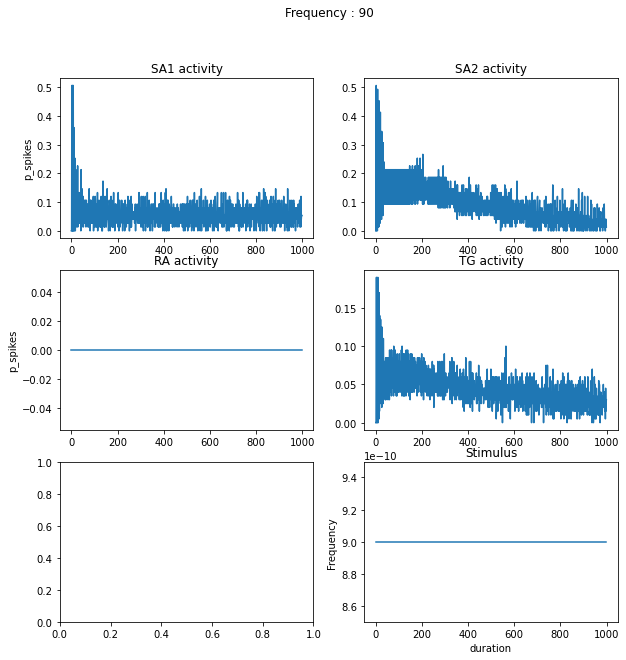

In [ ]:
model, statemon, spike_SA1, spike_SA2, spike_RA, spike_TG = model_mechano(fav_angles_SA1, fav_angles_SA2, fav_angles_RA)
I = TimedArray(np.ones(duration) * 900 * pA, dt=defaultclock.dt)
run_model(direction, amplitude, amplitudeOnOff, I, model, duration)
summarize_data(spike_SA1, spike_SA2, spike_RA, spike_TG, [], I.values, 'Frequency', duration, 'Frequency : ' + str(90))

# Direction decoding

In [ ]:
#Running the model for randomly picked direction range(360) with a step of 2 degrees
lst_direction = np.arange(360)#[1, 45, 90, 135, 170, 215, 270, 315]

duration = 1000
amplitude =  CreateAmplitude(90, duration)
amplitudeOnOff = CreateAmplitudeOnOff(amplitude.values, duration)
random_dir = []
SA1_activity = []
SA2_activity = []
RA_activity = []
TG_activity = []
for iteration in range(1000):
    rng_direction = rng.choice(lst_direction)
    direction =  CreateDirection(rng_direction, duration)
    model, statemon, spike_SA1, spike_SA2, spike_RA, spike_TG = model_mechano(fav_angles_SA1, fav_angles_SA2, fav_angles_RA)
    I = TimedArray(np.ones(duration) * 900 * pA, dt=defaultclock.dt)
    run_model(direction, amplitude, amplitudeOnOff, I, model, duration)
    random_dir.append(rng_direction)
    SA1_activity.append(compute_nb_spike_per_neuron(spike_SA1, 76))
    SA2_activity.append(compute_nb_spike_per_neuron(spike_SA2, 76))
    RA_activity.append(compute_nb_spike_per_neuron(spike_RA, 50))
    TG_activity.append(compute_nb_spike_per_neuron(spike_TG, 200))

In [ ]:
#Build training set
training_input_SA1 = SA1_activity
training_input_SA2 = SA2_activity
training_input_RA = RA_activity
training_input_TG = TG_activity
training_output = random_dir
y = training_output

In [ ]:
X = training_input_SA1
clf_SA1, mlp_SA1, gnb_SA1 = decoding_pipeline_training(X[:500], y[:500])
print(mutual_info_classif(X, y))

WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\linear_model\_glm\glm.py:287: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res)
 [py.warnings]


Linear decoder score : 0.957059082015878


WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]


MLP decoder score : 0.9939938861883262
Bayesian decoder score : 1.0
[3.93017356 3.76459028 3.90941467 3.93396446 3.82926821 3.86402749
 3.79377612 3.86579386 3.73971712 3.59348999 3.83464432 3.6050795
 3.68492757 3.80736223 3.75344329 3.83317182 3.7599704  3.84324249
 3.86056    3.8078032  3.75965408 3.73233226 3.65184902 3.86778216
 3.82136131 3.71110386 3.65351174 3.89316183 3.7845676  3.9017946
 3.83319416 3.71500653 3.80276378 3.79542082 3.80229036 3.8009774
 3.80605969 3.81954659 3.91416491 3.92945906 3.840828   3.79774094
 3.85598559 3.96628426 3.82219831 3.65273017 3.53932112 3.91461986
 3.79789569 3.61526352 3.73113646 3.89473529 3.88329706 3.9429717
 4.11091741 3.69020778 3.76149918 3.7974911  3.96153335 3.75067629
 3.80559267 3.76760104 3.60861848 3.70827898 3.68946198 4.01322712
 3.86336069 3.8829579  3.77701928 3.88371289 3.72421223 4.00306457
 3.94006324 3.89629761 3.77574608 3.85666205]


In [ ]:
X = training_input_SA2
clf_SA2, mlp_SA2, gnb_SA2 = decoding_pipeline_training(X, y)
print(mutual_info_classif(X, y))

WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\linear_model\_glm\link.py:90: RuntimeWarning: overflow encountered in exp
  return np.exp(lin_pred)
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\linear_model\_glm\link.py:93: RuntimeWarning: overflow encountered in exp
  return np.exp(lin_pred)
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\_loss\glm_distribution.py:132: RuntimeWarning: divide by zero encountered in true_divide
  return -2 * (y - y_pred) / self.unit_variance(y_pred)
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\_loss\glm_distribution.py:132: RuntimeWarning: overflow encountered in true_divide
  return -2 * (y - y_pred) / self.unit_variance(y_pred)
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\_loss\glm_distribution.py:132: RuntimeWar

Linear decoder score : 0.0


WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]


MLP decoder score : 0.9855890104806166
Bayesian decoder score : 1.0
[4.488967   4.43834305 4.58351258 4.54377338 4.42875337 4.28659709
 4.51114856 4.46350636 4.37473461 4.38483172 4.42989062 4.43668227
 4.47498423 4.39400175 4.3985056  4.46823805 4.40937213 4.54908427
 4.49058057 4.44446481 4.41728263 4.50120703 4.46086645 4.41490459
 4.54275697 4.55557614 4.44286171 4.48090337 4.41663496 4.49907889
 4.39196625 4.44168103 4.43781312 4.40840802 4.37559618 4.47519941
 4.41725209 4.44474145 4.44068069 4.44283904 4.31639962 4.43462713
 4.70828338 4.44470475 4.49529601 4.57668538 4.63583561 4.22055099
 4.5741966  4.41125395 4.49276626 4.6151878  4.59671556 4.71004043
 4.53177676 4.61237916 4.50304222 4.42145605 4.66144225 4.49213675
 4.69820937 4.54093004 4.50528543 4.46959536 4.44369478 4.42434052
 4.36010923 4.53918082 4.57112022 4.52192818 4.81679359 4.38746133
 4.49005684 4.57719277 4.32407738 4.58356239]


In [ ]:
X = training_input_RA
clf_RA, mlp_RA, gnb_RA = decoding_pipeline_training(X, y)
print(mutual_info_classif(X, y))

Linear decoder score : 0.0


WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\naive_bayes.py:452: RuntimeWarning: divide by zero encountered in log
  n_ij = - 0.5 * np.sum(np.log(2. * np.pi * self.sigma_[i, :]))
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\naive_bayes.py:453: RuntimeWarning: invalid value encountered in true_divide
  n_ij -= 0.5 * np.sum(((X - self.theta_[i, :]) ** 2) /
 [py.warnings]


MLP decoder score : -1.0781056146986145
Bayesian decoder score : 0.001
[0.01925891 0.00058605 0.00166454 0.         0.         0.0127279
 0.         0.         0.         0.02356567 0.         0.03669552
 0.02789041 0.         0.05266558 0.00136842 0.         0.
 0.00567378 0.         0.         0.         0.01410917 0.
 0.         0.         0.00799253 0.08204264 0.01400563 0.02999788
 0.05433547 0.01824353 0.         0.         0.         0.03220169
 0.         0.         0.         0.         0.01708919 0.00956154
 0.         0.         0.         0.         0.         0.02263503
 0.         0.04820665]


In [ ]:
X = training_input_TG
clf_TG, mlp_TG, gnb_TG = decoding_pipeline_training(X, y)
print(mutual_info_classif(X, y))

WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\linear_model\_glm\link.py:90: RuntimeWarning: overflow encountered in exp
  return np.exp(lin_pred)
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\linear_model\_glm\link.py:93: RuntimeWarning: overflow encountered in exp
  return np.exp(lin_pred)
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\_loss\glm_distribution.py:132: RuntimeWarning: divide by zero encountered in true_divide
  return -2 * (y - y_pred) / self.unit_variance(y_pred)
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\_loss\glm_distribution.py:132: RuntimeWarning: overflow encountered in true_divide
  return -2 * (y - y_pred) / self.unit_variance(y_pred)
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\_loss\glm_distribution.py:132: RuntimeWar

Linear decoder score : 0.0
MLP decoder score : 0.9877701253004585
Bayesian decoder score : 1.0
[4.60955102e+00 5.22575721e+00 4.64297412e+00 4.56543211e+00
 4.95070128e+00 4.73463395e+00 4.70393690e+00 4.74613154e+00
 4.45882065e+00 4.57525789e+00 4.74292230e+00 5.01298590e+00
 4.47858085e+00 4.48788332e+00 4.37159198e+00 4.42373092e+00
 5.30813806e+00 4.58085482e+00 4.64591808e+00 4.47301981e+00
 4.55719213e+00 4.58469333e+00 4.95199049e+00 5.28702742e+00
 4.43886695e+00 4.52366267e+00 4.52988443e+00 4.68312183e+00
 4.42891940e+00 4.57742976e+00 4.78237602e+00 4.49250404e+00
 4.48237809e+00 4.97793224e+00 4.46118143e+00 4.53279423e+00
 4.70692199e+00 4.87522194e+00 4.71622286e+00 4.57413576e+00
 4.41297328e+00 4.53998826e+00 4.83418303e+00 4.46789415e+00
 4.57012718e+00 4.87928543e+00 5.26059518e+00 4.95535768e+00
 4.69811159e+00 4.50653293e+00 4.67988419e+00 4.65139557e+00
 4.61878619e+00 4.68488786e+00 4.64358776e+00 4.96114827e+00
 4.80285913e+00 4.82140948e+00 4.82351090e+00 4.935

In [ ]:
sum_activity_SA1 = np.sum(SA1_activity, axis=1).T
sum_activity_SA2 = np.sum(SA2_activity, axis=1).T
sum_activity_RA = np.sum(RA_activity, axis=1).T
sum_activity_TG = np.sum(TG_activity, axis=1).T
training_input = np.asarray([sum_activity_SA1, sum_activity_SA2, sum_activity_RA, sum_activity_TG]).T
X = training_input
y = training_output
mutual_info_classif(X, y)

array([6.23096061, 6.07736888, 0.        , 6.09422465])